In [67]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import plotly.express as px

from sklearn.linear_model import LinearRegression 
from sklearn.preprocessing import LabelEncoder 
from sklearn.model_selection import train_test_split 
from sklearn.metrics import r2_score , mean_squared_error , accuracy_score

import warnings
warnings.filterwarnings("ignore")

In [68]:
df = pd.read_csv("breast-cancer.csv")
df

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [69]:
df.drop(columns=['id'] , inplace=True)

In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    object 
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  5

In [71]:
df.describe()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


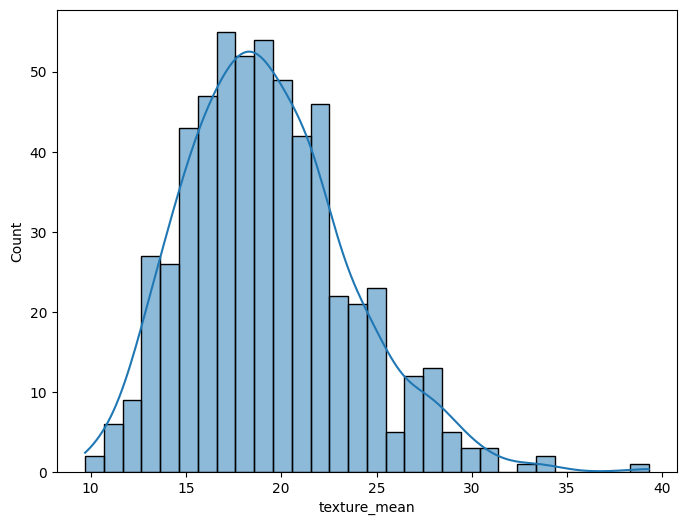

In [72]:
plt.figure(figsize=(8,6))
sns.histplot(data=df , x='texture_mean' , kde=True , bins=30)
plt.show()

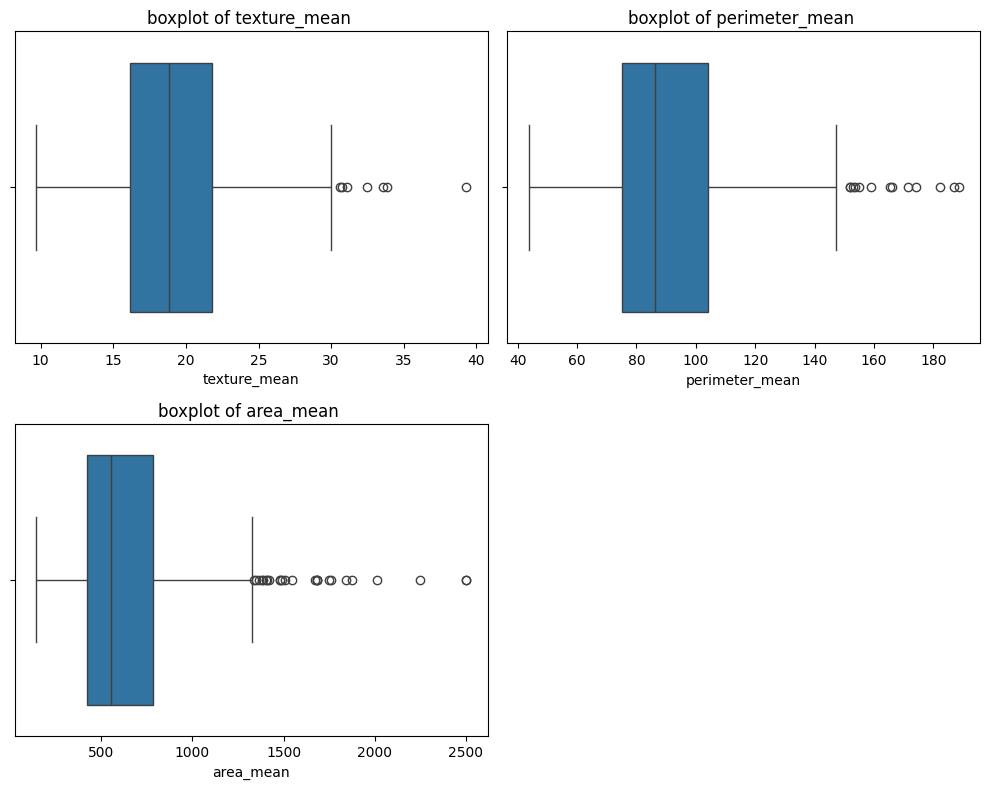

In [73]:
col = ['texture_mean' , 'perimeter_mean' , 'area_mean' ] 

plt.figure(figsize=(10,8))
for i , cols in enumerate(col , 1):
    plt.subplot(2,2 , i)
    
    sns.boxplot(data=df , x=cols)
    plt.title(f'boxplot of {cols} ')
    plt.tight_layout()
plt.show()

In [74]:
df

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [75]:
df.duplicated().sum()

np.int64(0)

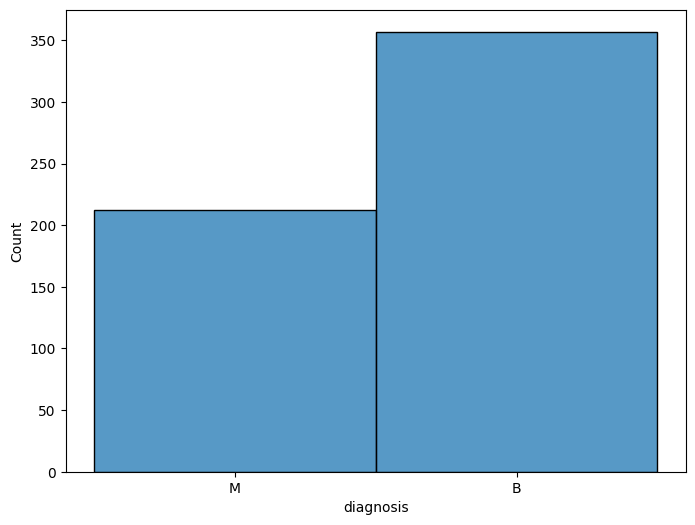

In [76]:
plt.figure(figsize=(8,6))
sns.histplot(data=df , x='diagnosis' )
plt.show()

In [85]:
df1 = df[df["diagnosis"] == 0]
df2 = df[df["diagnosis"] == 1]

ham_sampled = df2.sample(n=len(df1), replace=True, random_state=42)
df = pd.concat([df1, ham_sampled]).reset_index(drop=True)
print(df["diagnosis"].value_counts())

diagnosis
0    357
1    357
Name: count, dtype: int64


In [86]:
encoding = LabelEncoder()
encoding

LabelEncoder()

In [87]:
encoding.fit(df['diagnosis'])
df['diagnosis'] = encoding.transform(df['diagnosis'])

In [88]:
df

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,0,13.540,14.36,87.46,566.3,0.09779,0.08129,0.06664,0.047810,0.1885,...,15.110,19.26,99.70,711.2,0.14400,0.17730,0.23900,0.12880,0.2977,0.07259
1,0,13.080,15.71,85.63,520.0,0.10750,0.12700,0.04568,0.031100,0.1967,...,14.500,20.49,96.09,630.5,0.13120,0.27760,0.18900,0.07283,0.3184,0.08183
2,0,9.504,12.44,60.34,273.9,0.10240,0.06492,0.02956,0.020760,0.1815,...,10.230,15.66,65.13,314.9,0.13240,0.11480,0.08867,0.06227,0.2450,0.07773
3,0,13.030,18.42,82.61,523.8,0.08983,0.03766,0.02562,0.029230,0.1467,...,13.300,22.81,84.46,545.9,0.09701,0.04619,0.04833,0.05013,0.1987,0.06169
4,0,8.196,16.84,51.71,201.9,0.08600,0.05943,0.01588,0.005917,0.1769,...,8.964,21.96,57.26,242.2,0.12970,0.13570,0.06880,0.02564,0.3105,0.07409
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
709,1,13.000,21.82,87.50,519.8,0.12730,0.19320,0.18590,0.093530,0.2350,...,15.490,30.73,106.20,739.3,0.17030,0.54010,0.53900,0.20600,0.4378,0.10720
710,1,14.900,22.53,102.10,685.0,0.09947,0.22250,0.27330,0.097110,0.2041,...,16.350,27.57,125.40,832.7,0.14190,0.70900,0.90190,0.24750,0.2866,0.11550
711,1,16.740,21.59,110.10,869.5,0.09610,0.13360,0.13480,0.060180,0.1896,...,20.010,29.02,133.50,1229.0,0.15630,0.38350,0.54090,0.18130,0.4863,0.08633
712,1,19.180,22.49,127.50,1148.0,0.08523,0.14280,0.11140,0.067720,0.1767,...,23.360,32.06,166.40,1688.0,0.13220,0.56010,0.38650,0.17080,0.3193,0.09221


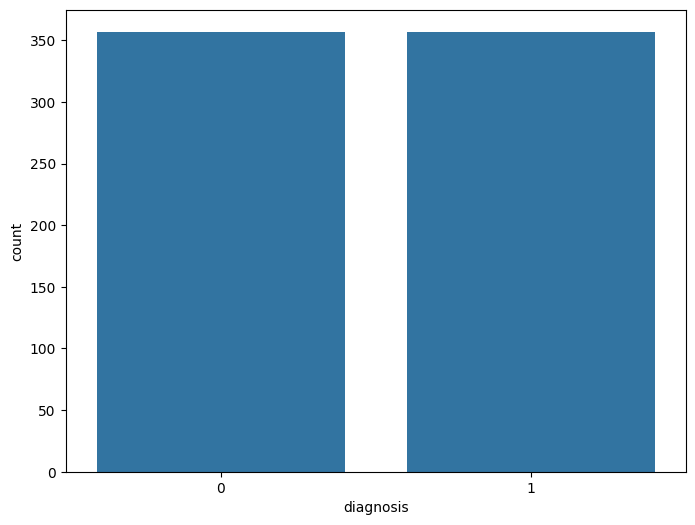

In [89]:
plt.figure(figsize=(8,6))
sns.countplot(data=df , x='diagnosis' )
plt.show()

In [90]:
from sklearn.preprocessing import StandardScaler , MinMaxScaler , RobustScaler

In [91]:
scaling = MinMaxScaler()
scaling

,feature_range,"(0, ...)"
,copy,True
,clip,False


In [92]:
cols_to_scale = [col for col in df.columns if df[col].max() > 1]
df[cols_to_scale] = scaling.fit_transform(df[cols_to_scale])

print(df.head())

   diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0          0     0.310426      0.192946        0.301776   0.179343   
1          0     0.288655      0.248963        0.289130   0.159703   
2          0     0.119409      0.113278        0.114367   0.055313   
3          0     0.286289      0.361411        0.268261   0.161315   
4          0     0.057504      0.295851        0.054730   0.024772   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.09779           0.08129         0.06664             0.047810   
1          0.10750           0.12700         0.04568             0.031100   
2          0.10240           0.06492         0.02956             0.020760   
3          0.08983           0.03766         0.02562             0.029230   
4          0.08600           0.05943         0.01588             0.005917   

   symmetry_mean  ...  radius_worst  texture_worst  perimeter_worst  \
0         0.1885  ...      0.255425       0.2

In [93]:
df

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,0,0.310426,0.192946,0.301776,0.179343,0.09779,0.08129,0.06664,0.047810,0.1885,...,0.255425,0.206033,0.245480,0.129276,0.14400,0.17730,0.190895,0.12880,0.2977,0.07259
1,0,0.288655,0.248963,0.289130,0.159703,0.10750,0.12700,0.04568,0.031100,0.1967,...,0.233725,0.241036,0.227501,0.109443,0.13120,0.27760,0.150958,0.07283,0.3184,0.08183
2,0,0.119409,0.113278,0.114367,0.055313,0.10240,0.06492,0.02956,0.020760,0.1815,...,0.081821,0.103586,0.073310,0.031877,0.13240,0.11480,0.070823,0.06227,0.2450,0.07773
3,0,0.286289,0.361411,0.268261,0.161315,0.08983,0.03766,0.02562,0.029230,0.1467,...,0.191035,0.307057,0.169580,0.088650,0.09701,0.04619,0.038602,0.05013,0.1987,0.06169
4,0,0.057504,0.295851,0.054730,0.024772,0.08600,0.05943,0.01588,0.005917,0.1769,...,0.036784,0.282869,0.034115,0.014009,0.12970,0.13570,0.054952,0.02564,0.3105,0.07409
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
709,1,0.284869,0.502490,0.302052,0.159618,0.12730,0.19320,0.18590,0.093530,0.2350,...,0.268943,0.532442,0.277852,0.136183,0.17030,0.54010,0.430511,0.20600,0.4378,0.10720
710,1,0.374793,0.531950,0.402944,0.229692,0.09947,0.22250,0.27330,0.097110,0.2041,...,0.299538,0.442516,0.373475,0.159138,0.14190,0.70900,0.720367,0.24750,0.2866,0.11550
711,1,0.461877,0.492946,0.458227,0.307953,0.09610,0.13360,0.13480,0.060180,0.1896,...,0.429740,0.483779,0.413815,0.256538,0.15630,0.38350,0.432029,0.18130,0.4863,0.08633
712,1,0.577358,0.530290,0.578467,0.426087,0.08523,0.14280,0.11140,0.067720,0.1767,...,0.548915,0.570290,0.577668,0.369347,0.13220,0.56010,0.308706,0.17080,0.3193,0.09221


In [94]:
x = df.drop(columns=['diagnosis'])
y = df['diagnosis']

In [95]:
x_train , x_test , y_train , y_test = train_test_split(x,y, train_size=0.8 , random_state=42)

In [96]:
from sklearn.linear_model import Ridge , LogisticRegression 
from sklearn.ensemble import RandomForestClassifier

In [99]:
#re = Ridge(alpha=50, max_iter=100 , tol=0.1)
#re

In [100]:
#re.fit(x_train,y_train)

In [101]:
#re.score(x_train,y_train)

In [102]:
#re.score(x_test , y_test)

In [103]:
from sklearn.svm import SVC
log =LogisticRegression()
log

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [104]:
log.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [105]:
log.score(x_train,y_train)

0.9562171628721541

In [106]:
log.score(x_test,y_test)

0.951048951048951

In [107]:
y_pred = log.predict(x_test)
y_pred

array([0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0,
       1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1,
       1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1,
       1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0])

In [108]:
from sklearn.metrics import classification_report 

In [109]:
print(classification_report(y_test , y_pred))

              precision    recall  f1-score   support

           0       0.94      0.98      0.96        81
           1       0.97      0.92      0.94        62

    accuracy                           0.95       143
   macro avg       0.95      0.95      0.95       143
weighted avg       0.95      0.95      0.95       143



In [110]:
from sklearn.metrics import confusion_matrix

In [111]:
co = confusion_matrix(y_test , y_pred)
co

array([[79,  2],
       [ 5, 57]])

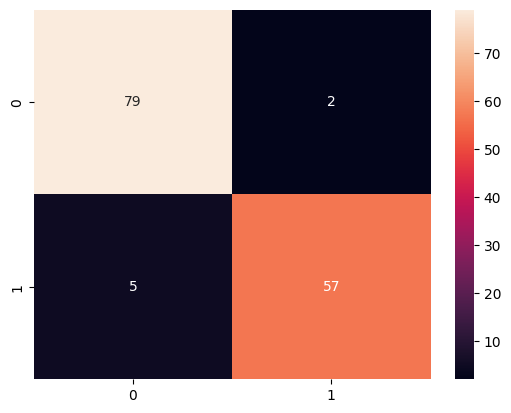

In [112]:
sns.heatmap(data=co , annot=True )
plt.show()

In [113]:
print(f'accuracy : {accuracy_score(y_test , y_pred)}')

accuracy : 0.951048951048951


In [114]:
import joblib
joblib.dump(df,"cancer_model.pkl")

['cancer_model.pkl']